In [3]:
!pip install -U scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.2 MB 13.7 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 19.8 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/36.6 MB 18.6 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.6 MB 18.7 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.6 MB 18.6 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.6 MB 18.5 MB/s eta 0:00:01
   ------------------------ --------------- 22.8/36.6 MB 18.6 MB/s eta 0:00:01
   ----------------------------- ---------- 26.7/36.6 MB 18.6 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

In [24]:
df = pd.read_csv('spotifydataset.csv')
print(df.head())

   Unnamed: 0    artist_name genres  followers  artist_popularity  \
0           0  Ariana Grande    pop   98934105                 89   
1           1  Ariana Grande    pop   98934105                 85   
2           2  Ariana Grande    pop   98934105                 83   
3           3  Ariana Grande    pop   98934105                 80   
4           4  Ariana Grande    pop   98934105                 79   

                                          artist_url  \
0  https://open.spotify.com/artist/66CXWjxzNUsdJx...   
1  https://open.spotify.com/artist/66CXWjxzNUsdJx...   
2  https://open.spotify.com/artist/66CXWjxzNUsdJx...   
3  https://open.spotify.com/artist/66CXWjxzNUsdJx...   
4  https://open.spotify.com/artist/66CXWjxzNUsdJx...   

                                          track_name            album_name  \
0           we can't be friends (wait for your love)      eternal sunshine   
1                                    the boy is mine      eternal sunshine   
2             

In [25]:
print(df.columns)

Index(['Unnamed: 0', 'artist_name', 'genres', 'followers', 'artist_popularity',
       'artist_url', 'track_name', 'album_name', 'release_date', 'duration_ms',
       'explicit', 'track_popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo'],
      dtype='str')


In [26]:
columnas_canciones = [
    'track_popularity', 'danceability', 'energy', 'key', 'loudness', 
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'valence', 'tempo'
]



In [28]:
df_filtrado = df[columnas_canciones]
df_limpio = df_filtrado.dropna()
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_limpio)
df_escalado = pd.DataFrame(datos_escalados, columns=columnas_canciones)
df_escalado.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.238679,0.200823,-0.070192,-0.067277,-0.262122,0.794557,-0.538762,-0.707668,-0.331336,-0.789715,-0.952150,-0.224734
1,1.071126,1.098154,-0.147313,0.486445,0.291770,-1.258562,-0.531018,-0.376933,-0.331471,-0.795218,-0.299172,-0.861119
2,0.987349,-0.630704,-1.439104,1.317029,-0.518074,0.794557,-0.550930,1.399684,-0.331471,-0.088114,-0.565518,-1.334449
3,0.861684,0.230734,0.792609,-1.451583,0.561793,0.794557,-0.651599,-0.846195,-0.331363,-0.654898,0.328030,-0.144526
4,0.819796,1.050296,0.551603,-1.174722,0.122029,0.794557,-0.404905,-0.262648,-0.331181,-0.521456,1.161436,-0.112179


In [30]:
from sklearn.decomposition import PCA

In [31]:
# 1. Configurar PCA para reducir los datos a 2 componentes
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(df_escalado)

# 2. Guardar los componentes en un nuevo DataFrame limpio
df_pca = pd.DataFrame(data=componentes_principales, columns=['Componente 1', 'Componente 2'])

# 3. Calcular el porcentaje de información que logramos retener
varianza_explicada = pca.explained_variance_ratio_ * 100
print(f"¡Reducción completada!")
print(f"El Componente 1 retiene el {varianza_explicada[0]:.2f}% de la información.")
print(f"El Componente 2 retiene el {varianza_explicada[1]:.2f}% de la información.")
print(f"Información total retenida en 2D: {sum(varianza_explicada):.2f}%\n")

# Mostrar cómo se ven tus datos ahora en 2D
df_pca.head()


¡Reducción completada!
El Componente 1 retiene el 24.91% de la información.
El Componente 2 retiene el 12.77% de la información.
Información total retenida en 2D: 37.68%



,Componente 1,Componente 2
0,0.063185,0.129111
1,0.609885,1.542816
2,-1.725773,1.120047
3,1.178713,-0.074323
4,1.060287,0.941007


In [34]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

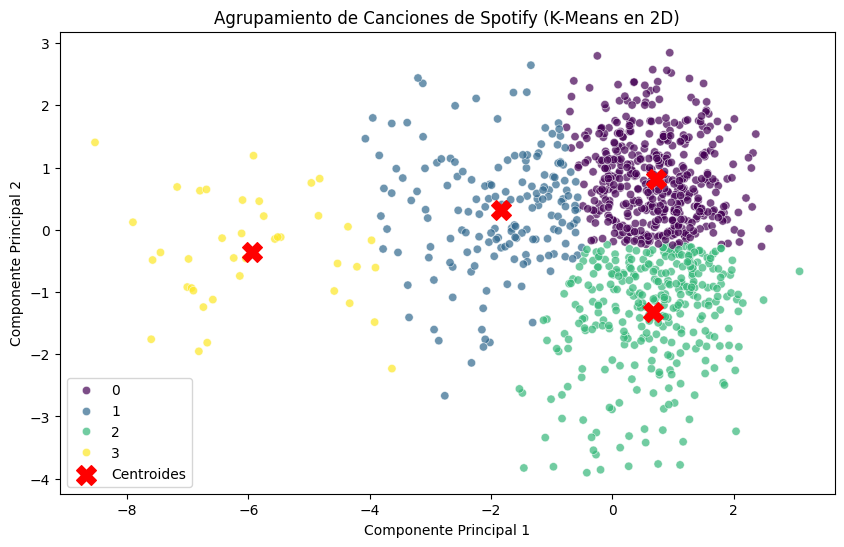

In [36]:
# 1. Configurar el modelo K-Means (definimos 4 grupos o clusters como ejemplo)
# Puedes cambiar n_clusters por el número que te pida tu profesor
kmeans = KMeans(n_clusters=4, random_state=42)

# 2. Entrenar el modelo usando los datos reducidos de PCA
clusters = kmeans.fit_predict(df_pca)

# 3. Guardar las etiquetas de los grupos en nuestro DataFrame de visualización
df_pca['Cluster'] = clusters

# 4. Crear la gráfica para visualizar cómo quedaron agrupadas las canciones
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Componente 1', 
    y='Componente 2', 
    hue='Cluster', 
    palette='viridis', 
    data=df_pca, 
    alpha=0.7
)

# 5. Dibujar los centros de cada grupo (Centroides)
plt.scatter(
    kmeans.cluster_centers_[:, 0], 
    kmeans.cluster_centers_[:, 1], 
    s=200, 
    c='red', 
    marker='X', 
    label='Centroides'
)

plt.title('Agrupamiento de Canciones de Spotify (K-Means en 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()


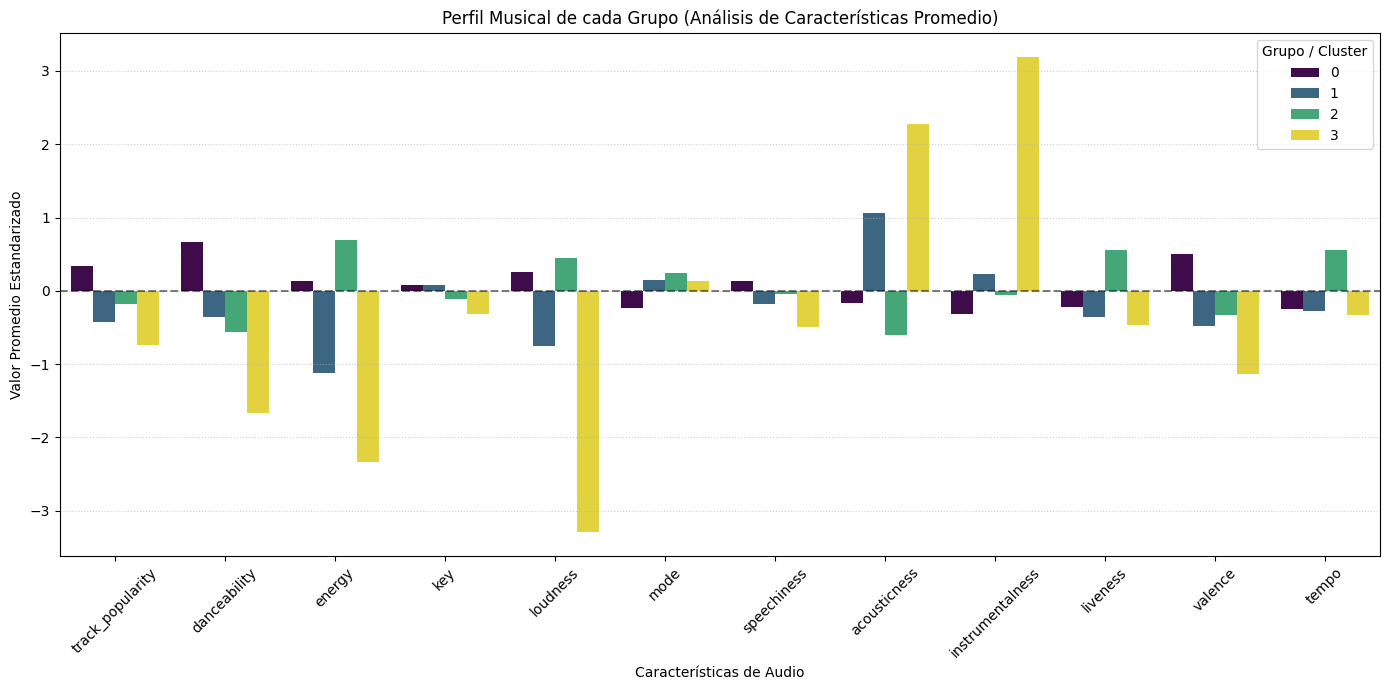

In [37]:
# 1. Unir la etiqueta del Cluster con los datos escalados originales
df_analisis = df_escalado.copy()
df_analisis['Cluster'] = df_pca['Cluster']

# 2. Calcular el valor promedio de cada característica por cada grupo
df_promedios = df_analisis.groupby('Cluster').mean().reset_index()

# 3. Transformar los datos para poder graficarlos fácilmente con Seaborn
df_melt = pd.melt(df_promedios, id_vars=['Cluster'], var_name='Caracteristica', value_name='Valor_Promedio')

# 4. Crear el gráfico de barras comparativo
plt.figure(figsize=(14, 7))
sns.barplot(
    x='Caracteristica', 
    y='Valor_Promedio', 
    hue='Cluster', 
    data=df_melt, 
    palette='viridis'
)

plt.title('Perfil Musical de cada Grupo (Análisis de Características Promedio)')
plt.xlabel('Características de Audio')
plt.ylabel('Valor Promedio Estandarizado')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea base (promedio general)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(title='Grupo / Cluster')
plt.tight_layout()
plt.show()


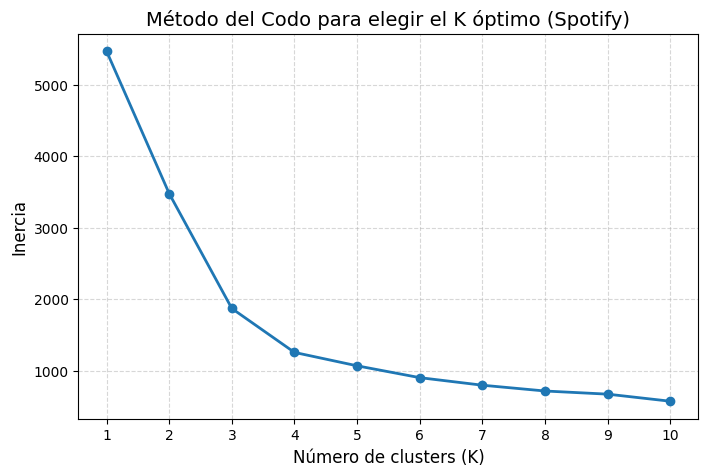

In [38]:
# 1. Crear una lista vacía para almacenar las inercias (distancias internas)
inercias = []
k_range = range(1, 11)

# 2. Probar el algoritmo K-Means con diferentes números de grupos (del 1 al 10)
for k in k_range:
    # Usamos n_init='auto' para evitar advertencias de futuras actualizaciones
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(df_pca)
    inercias.append(km.inertia_)

# 3. Dibujar la gráfica del Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inercias, marker='o', linewidth=2, color='#1f77b4')
plt.title('Método del Codo para elegir el K óptimo (Spotify)', fontsize=14)
plt.xlabel('Número de clusters (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
